<a href="https://colab.research.google.com/github/adityab-tech/Prism/blob/main/W2_Prism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
pd.set_option("display.max_columns", None)

# Better plot size
plt.rcParams["figure.figsize"] = (15,5)

In [4]:
df = pd.read_csv(
    "/content/drive/MyDrive/PRISM/raw_data/TCS.NS.csv",
    header=[0,1]
)
df.columns = df.columns.get_level_values(0)

# Remove the first row (which contains "Date")
df = df.iloc[1:].reset_index(drop=True)
df.rename(columns={"Price": "Date"}, inplace=True)

In [5]:
df.head()

,Date,Close,High,Low,Open,Volume
0,2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883.0
1,2019-01-02,1577.818115,1586.965163,1558.703449,1562.805300,2100463.0
2,2019-01-03,1558.662231,1595.578888,1553.042716,1574.290323,2611668.0
3,2019-01-04,1539.711670,1559.687663,1510.301421,1558.703259,4280862.0
4,2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423.0


In [6]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True) #setting date as index

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1481 entries, 2019-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1481 non-null   float64
 1   High    1481 non-null   float64
 2   Low     1481 non-null   float64
 3   Open    1481 non-null   float64
 4   Volume  1481 non-null   float64
dtypes: float64(5)
memory usage: 69.4 KB


In [8]:
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883.0
2019-01-02,1577.818115,1586.965163,1558.703449,1562.805300,2100463.0
2019-01-03,1558.662231,1595.578888,1553.042716,1574.290323,2611668.0
2019-01-04,1539.711670,1559.687663,1510.301421,1558.703259,4280862.0
2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423.0


In [9]:
df.isnull().sum()

,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,1481.000000,1481.000000,1481.000000,1481.000000,1.481000e+03
mean,2751.234889,2778.450887,2724.831641,2752.136326,2.745963e+06
std,735.664112,739.792072,731.702848,735.225567,1.660880e+06
min,1403.242798,1445.348208,1282.136856,1337.511997,1.548950e+05
25%,1901.626953,1923.109838,1878.140800,1900.743332,1.711510e+06
50%,2889.345215,2914.741276,2863.072432,2889.963693,2.316539e+06
75%,3231.118408,3254.525132,3205.212154,3234.932032,3.224657e+06
max,4253.905762,4289.870707,4214.905459,4274.691352,1.983933e+07


In [11]:
df.shape

(1481, 5)

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df = df.dropna()

In [14]:
df["return"] = df["Close"].pct_change()

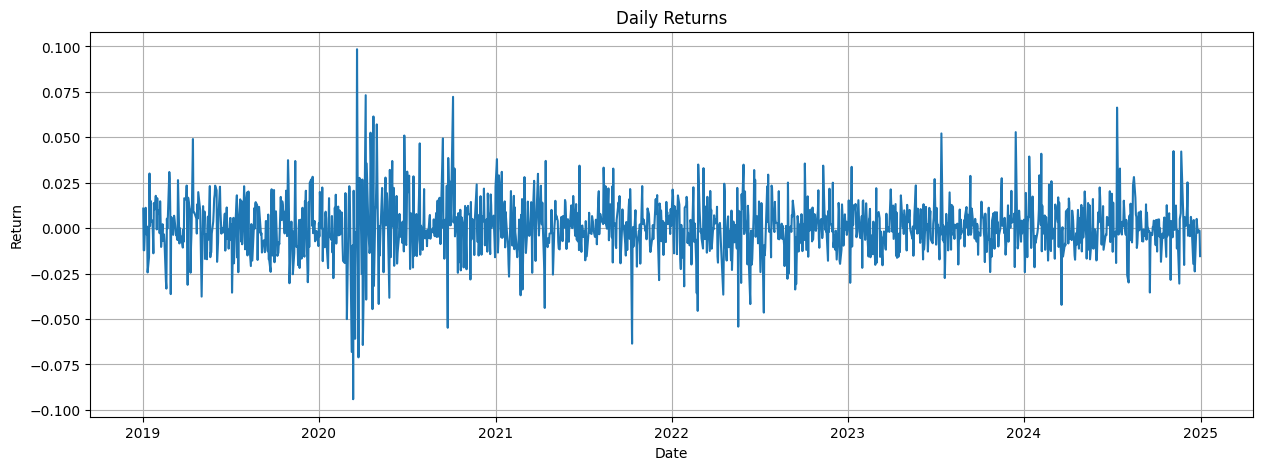

In [15]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["return"])
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

In [16]:
df["log_return"] = np.log(      #ts is the most imp concept of how to calculate returns
    df["Close"] /
    df["Close"].shift(1)
)

In [17]:
df[["Close","return"]].head(10)

,Close,return
Date,,
2019-01-01,1561.000366,NaN
2019-01-02,1577.818115,0.010774
2019-01-03,1558.662231,-0.012141
2019-01-04,1539.711670,-0.012158
2019-01-07,1556.980835,0.011216
2019-01-08,1553.412354,-0.002292
2019-01-09,1547.997314,-0.003486
2019-01-10,1549.310059,0.000848
2019-01-11,1511.573242,-0.024357


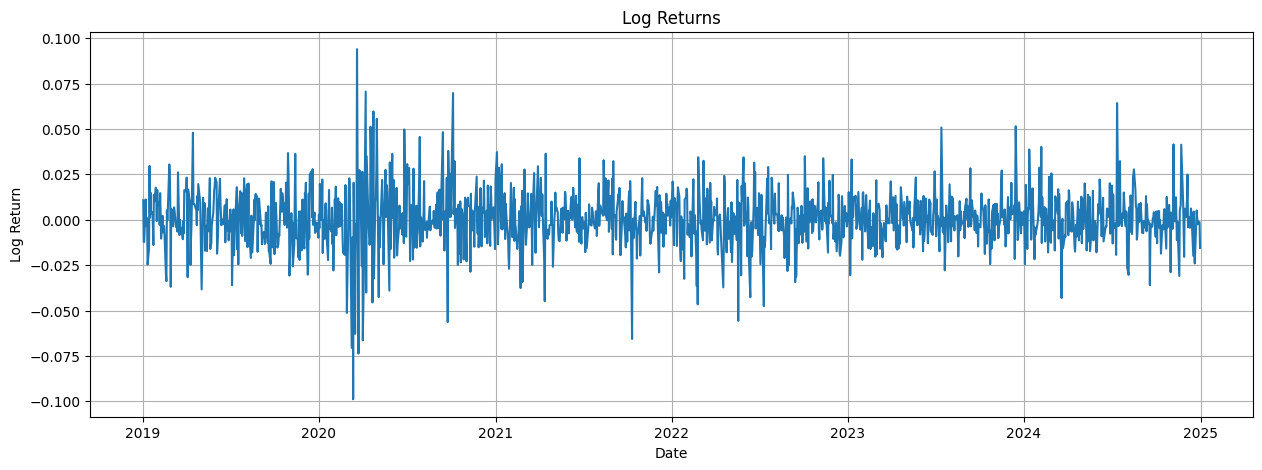

In [18]:
plt.figure(figsize=(15,5))
plt.plot(df.index, df["log_return"])
plt.title("Log Returns")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.grid(True)
plt.show()

In [19]:
print(df[["Close", "return", "log_return"]].head(10))

                  Close    return  log_return
Date                                         
2019-01-01  1561.000366       NaN         NaN
2019-01-02  1577.818115  0.010774    0.010716
2019-01-03  1558.662231 -0.012141   -0.012215
2019-01-04  1539.711670 -0.012158   -0.012233
2019-01-07  1556.980835  0.011216    0.011153
2019-01-08  1553.412354 -0.002292   -0.002295
2019-01-09  1547.997314 -0.003486   -0.003492
2019-01-10  1549.310059  0.000848    0.000848
2019-01-11  1511.573242 -0.024357   -0.024659
2019-01-14  1487.536377 -0.015902   -0.016030


In [20]:
print(df[["return", "log_return"]].describe())

            return   log_return
count  1480.000000  1480.000000
mean      0.000724     0.000607
std       0.015253     0.015250
min      -0.094104    -0.098830
25%      -0.006960    -0.006984
50%       0.000519     0.000518
75%       0.008536     0.008500
max       0.098451     0.093901


In [21]:
df["MA5"] = df["Close"].rolling(window=5).mean()

# 10-Day Moving Average
df["MA10"] = df["Close"].rolling(window=10).mean()

# 20-Day Moving Average
df["MA20"] = df["Close"].rolling(window=20).mean()

In [22]:
# Check
df[["Close", "MA5", "MA10", "MA20"]].head(25)

,Close,MA5,MA10,MA20
Date,,,,
2019-01-01,1561.000366,NaN,NaN,NaN
2019-01-02,1577.818115,NaN,NaN,NaN
2019-01-03,1558.662231,NaN,NaN,NaN
2019-01-04,1539.711670,NaN,NaN,NaN
2019-01-07,1556.980835,1558.834644,NaN,NaN
2019-01-08,1553.412354,1557.317041,NaN,NaN
2019-01-09,1547.997314,1551.352881,NaN,NaN
2019-01-10,1549.310059,1549.482446,NaN,NaN
2019-01-11,1511.573242,1543.854761,NaN,NaN


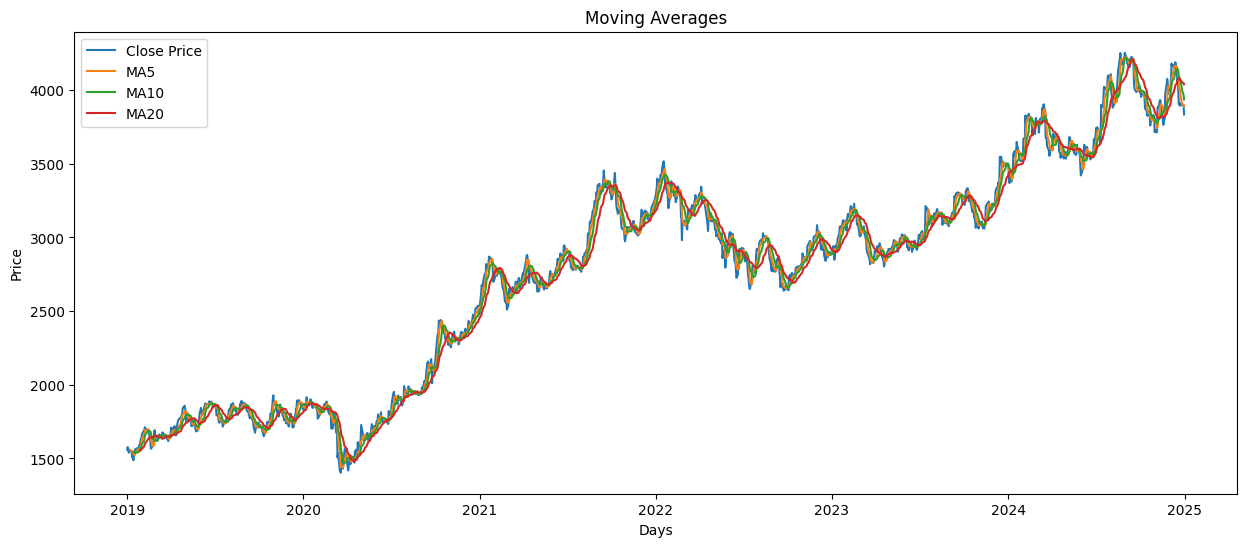

In [23]:
plt.figure(figsize=(15,6))
plt.plot(df["Close"], label="Close Price")
plt.plot(df["MA5"], label="MA5")
plt.plot(df["MA10"], label="MA10")
plt.plot(df["MA20"], label="MA20")
plt.title("Moving Averages")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.show()

In [24]:
# 20-Day Rolling Volatility
df["Volatility"] = df["return"].rolling(window=20).std()

# Check
df[["return", "Volatility"]].head(25)

,return,Volatility
Date,,
2019-01-01,NaN,NaN
2019-01-02,0.010774,NaN
2019-01-03,-0.012141,NaN
2019-01-04,-0.012158,NaN
2019-01-07,0.011216,NaN
2019-01-08,-0.002292,NaN
2019-01-09,-0.003486,NaN
2019-01-10,0.000848,NaN
2019-01-11,-0.024357,NaN


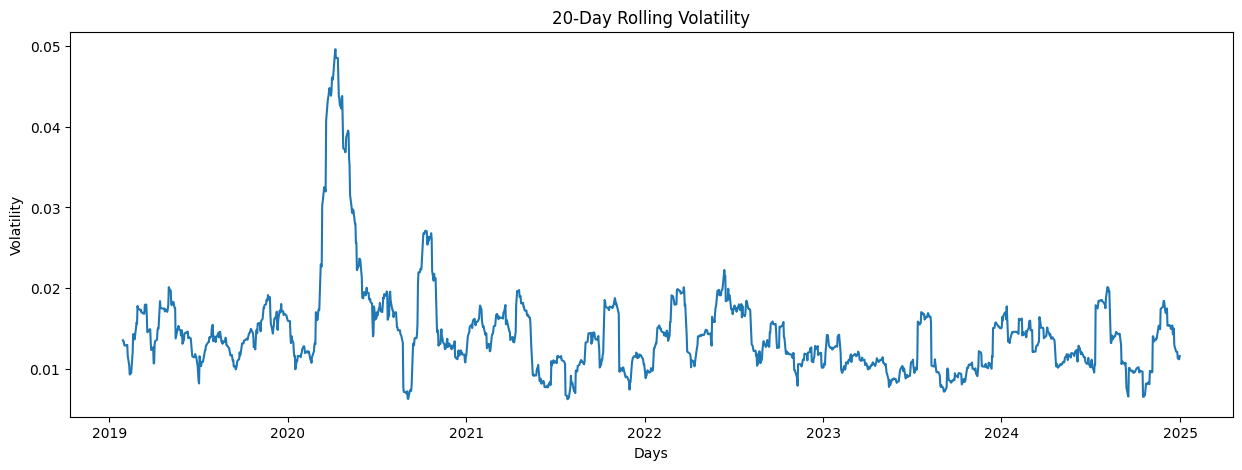

In [25]:
plt.figure(figsize=(15,5))

plt.plot(df["Volatility"])

plt.title("20-Day Rolling Volatility")
plt.xlabel("Days")
plt.ylabel("Volatility")

plt.show()

In [26]:
df["Volume_Change"] = df["Volume"].pct_change()
df["Volume_MA20"] = df["Volume"].rolling(window=20).mean()
df[["Volume", "Volume_Change", "Volume_MA20"]].head(25)

,Volume,Volume_Change,Volume_MA20
Date,,,
2019-01-01,1094883.0,NaN,NaN
2019-01-02,2100463.0,0.918436,NaN
2019-01-03,2611668.0,0.243377,NaN
2019-01-04,4280862.0,0.639129,NaN
2019-01-07,1856423.0,-0.566344,NaN
2019-01-08,1691756.0,-0.088701,NaN
2019-01-09,2414376.0,0.427142,NaN
2019-01-10,3053461.0,0.264700,NaN
2019-01-11,9209862.0,2.016204,NaN


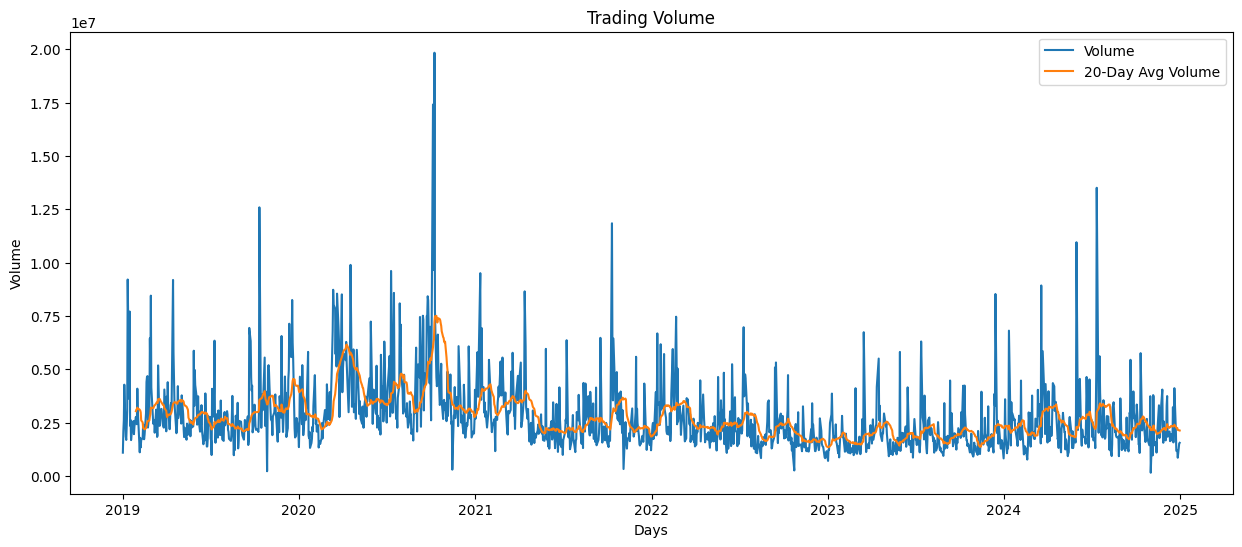

In [27]:
plt.figure(figsize=(15,6))

plt.plot(df["Volume"], label="Volume")
plt.plot(df["Volume_MA20"], label="20-Day Avg Volume")

plt.title("Trading Volume")
plt.xlabel("Days")
plt.ylabel("Volume")

plt.legend()

plt.show()

In [28]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'return', 'log_return', 'MA5',
       'MA10', 'MA20', 'Volatility', 'Volume_Change', 'Volume_MA20'],
      dtype='object')


In [29]:
df.head(25)

,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20
Date,,,,,,,,,,,,,
2019-01-01,1561.000366,1566.906991,1546.397737,1555.421809,1094883.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-02,1577.818115,1586.965163,1558.703449,1562.805300,2100463.0,0.010774,0.010716,NaN,NaN,NaN,NaN,0.918436,NaN
2019-01-03,1558.662231,1595.578888,1553.042716,1574.290323,2611668.0,-0.012141,-0.012215,NaN,NaN,NaN,NaN,0.243377,NaN
2019-01-04,1539.711670,1559.687663,1510.301421,1558.703259,4280862.0,-0.012158,-0.012233,NaN,NaN,NaN,NaN,0.639129,NaN
2019-01-07,1556.980835,1565.922891,1543.116557,1551.976596,1856423.0,0.011216,0.011153,1558.834644,NaN,NaN,NaN,-0.566344,NaN
2019-01-08,1553.412354,1563.954093,1545.003557,1563.133722,1691756.0,-0.002292,-0.002295,1557.317041,NaN,NaN,NaN,-0.088701,NaN
2019-01-09,1547.997314,1574.290216,1531.384820,1564.773943,2414376.0,-0.003486,-0.003492,1551.352881,NaN,NaN,NaN,0.427142,NaN
2019-01-10,1549.310059,1562.805107,1535.814910,1550.499555,3053461.0,0.000848,0.000848,1549.482446,NaN,NaN,NaN,0.264700,NaN
2019-01-11,1511.573242,1538.194217,1505.379407,1534.092365,9209862.0,-0.024357,-0.024659,1543.854761,NaN,NaN,NaN,2.016204,NaN


In [30]:
import yfinance as yf

nifty = yf.download(
    "^NSEI",
    start="2019-01-01",
    end="2025-01-01",
    auto_adjust=False
)

nifty.reset_index(inplace=True)

nifty.to_csv(
    "/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv",
    index=False
)

[*********************100%***********************]  1 of 1 completed


In [31]:
nifty = pd.read_csv("/content/drive/MyDrive/PRISM/raw_data/^NSEI.csv")

In [32]:
nifty = nifty.iloc[1:].reset_index(drop=True)

In [33]:
nifty.head()

,Date,Adj Close,Close,High,Low,Open,Volume
0,2019-01-02,10792.5,10792.5,10895.349609375,10735.0498046875,10868.849609375,309700
1,2019-01-03,10672.25,10672.25,10814.0498046875,10661.25,10796.7998046875,286200
2,2019-01-04,10727.349609375,10727.349609375,10741.0498046875,10628.650390625,10699.7001953125,296600
3,2019-01-07,10771.7998046875,10771.7998046875,10835.9501953125,10750.150390625,10804.849609375,269400
4,2019-01-08,10802.150390625,10802.150390625,10818.4501953125,10733.25,10786.25,277700


In [34]:
nifty["Date"] = pd.to_datetime(nifty["Date"])

In [35]:
print(nifty.dtypes)

Date         datetime64[ns]
Adj Close            object
Close                object
High                 object
Low                  object
Open                 object
Volume               object
dtype: object


In [36]:
nifty["Close"] = pd.to_numeric(nifty["Close"], errors="coerce")      #converting object into float64

In [37]:
nifty["market_return"] = nifty["Close"].pct_change()

In [38]:
nifty = nifty[["Date", "market_return"]]

In [39]:
df = pd.merge(
    df,
    nifty,
    on="Date",
    how="inner"
)

In [40]:
covariance = (
    df["return"]
    .rolling(60)
    .cov(df["market_return"])
)

variance = (
    df["market_return"]
    .rolling(60)
    .var()
)

df["beta"] = covariance / variance

In [41]:
df[["return","market_return","beta"]].tail()

,return,market_return,beta
1473,0.005098,-0.001086,0.986703
1474,-0.002488,0.000950,0.983653
1475,-0.001019,0.002661,0.989637
1476,-0.001453,-0.007076,0.982377
1477,-0.015389,-0.000004,1.016129


In [42]:
df["beta"].describe()

,beta
count,1418.000000
mean,0.712281
std,0.279786
min,-0.154951
25%,0.571874
50%,0.749855
75%,0.910399
max,1.298475


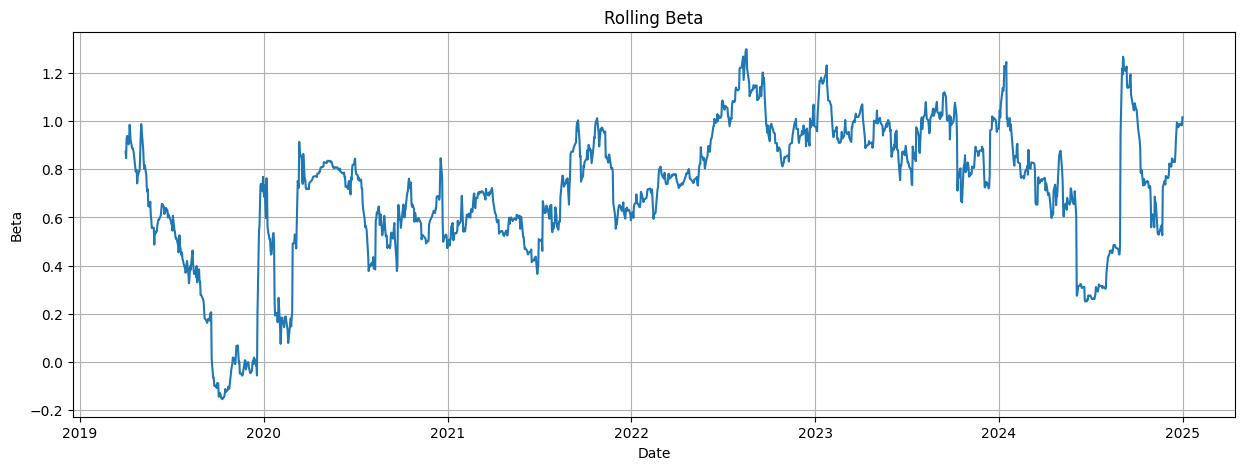

In [43]:
plt.figure(figsize=(15,5))
plt.plot(df["Date"], df["beta"])
plt.title("Rolling Beta")
plt.xlabel("Date")
plt.ylabel("Beta")
plt.grid(True)
plt.show()

In [44]:
df["target"] = df["return"].shift(-1)

In [45]:
df[["return","target"]].head(10)

,return,target
0,0.010774,-0.012141
1,-0.012141,-0.012158
2,-0.012158,0.011216
3,0.011216,-0.002292
4,-0.002292,-0.003486
5,-0.003486,0.000848
6,0.000848,-0.024357
7,-0.024357,-0.015902
8,-0.015902,0.030084
9,0.030084,0.001258


In [46]:
df.dropna(inplace=True) #as my last row has no tomorrow kyuki ghee khtm

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1417 entries, 60 to 1476
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1417 non-null   datetime64[ns]
 1   Close          1417 non-null   float64       
 2   High           1417 non-null   float64       
 3   Low            1417 non-null   float64       
 4   Open           1417 non-null   float64       
 5   Volume         1417 non-null   float64       
 6   return         1417 non-null   float64       
 7   log_return     1417 non-null   float64       
 8   MA5            1417 non-null   float64       
 9   MA10           1417 non-null   float64       
 10  MA20           1417 non-null   float64       
 11  Volatility     1417 non-null   float64       
 12  Volume_Change  1417 non-null   float64       
 13  Volume_MA20    1417 non-null   float64       
 14  market_return  1417 non-null   float64       
 15  beta           1417 non-n

In [48]:
df.tail()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
1472,2024-12-23,3893.971680,3948.940515,3853.330553,3933.067783,2195338.0,-0.002877,-0.002882,3984.871289,4071.697363,4072.427698,0.012251,-0.466761,2310755.70,0.007035,0.974476,0.005098
1473,2024-12-24,3913.824463,3949.877159,3893.971886,3893.971886,1181886.0,0.005098,0.005085,3956.965674,4048.001001,4064.318176,0.012114,-0.461638,2266816.55,-0.001086,0.986703,-0.002488
1474,2024-12-26,3904.085449,3932.974517,3879.784814,3913.824267,1208464.0,-0.002488,-0.002491,3923.488184,4023.808276,4056.665222,0.012099,0.022488,2249290.10,0.000950,0.983653,-0.001019
1475,2024-12-27,3900.105469,3915.182141,3883.624146,3898.372975,858100.0,-0.001019,-0.001020,3903.439160,3996.642310,4052.917188,0.011299,-0.289925,2164267.90,0.002661,0.989637,-0.001453
1476,2024-12-30,3894.439941,3932.365503,3850.615031,3887.135942,1527169.0,-0.001453,-0.001454,3901.285400,3967.135278,4047.670813,0.011178,0.779710,2139755.10,-0.007076,0.982377,-0.015389


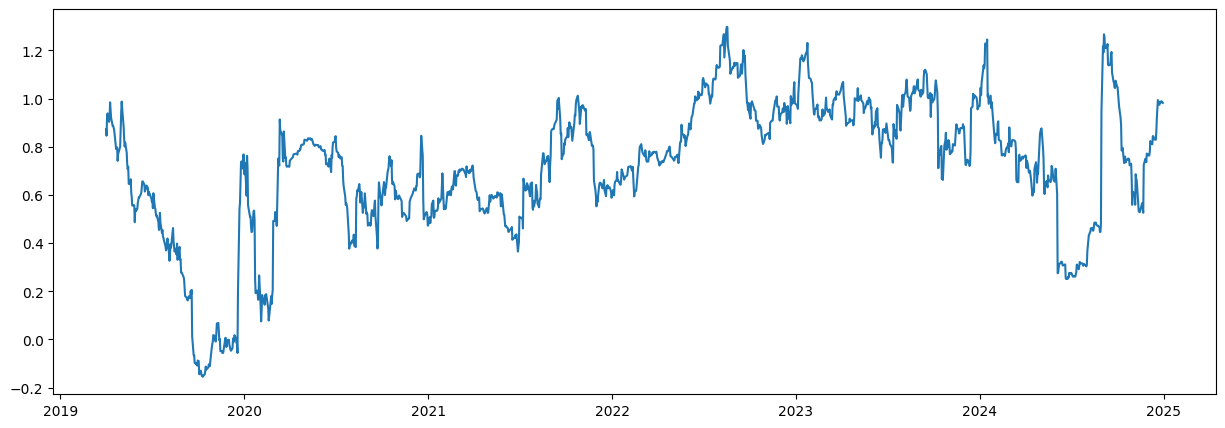

In [49]:
plt.plot(df["Date"], df["beta"])

In [50]:
features = ["return","log_return","MA5","MA10","MA20","Volatility","Volume_Change","Volume_MA20","market_return","beta","target"]
corr = df[features].corr()
corr

,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
return,1.000000,0.999805,-0.028083,-0.032135,-0.033690,0.017598,0.031052,0.040563,0.543053,-0.028651,-0.030686
log_return,0.999805,1.000000,-0.024857,-0.028969,-0.030615,0.009838,0.026888,0.036306,0.545308,-0.028763,-0.030147
MA5,-0.028083,-0.024857,1.000000,0.998698,0.994674,-0.374437,-0.001639,-0.483999,-0.001589,0.393508,-0.037811
MA10,-0.032135,-0.028969,0.998698,1.000000,0.997674,-0.374604,-0.001649,-0.487300,-0.005064,0.397194,-0.036610
MA20,-0.033690,-0.030615,0.994674,0.997674,1.000000,-0.374353,-0.000840,-0.494060,-0.007074,0.400687,-0.035826
Volatility,0.017598,0.009838,-0.374437,-0.374604,-0.374353,1.000000,-0.007373,0.704002,0.001925,-0.002688,0.015640
Volume_Change,0.031052,0.026888,-0.001639,-0.001649,-0.000840,-0.007373,1.000000,0.000446,-0.005138,-0.045814,0.044180
Volume_MA20,0.040563,0.036306,-0.483999,-0.487300,-0.494060,0.704002,0.000446,1.000000,0.031907,-0.305370,0.037361
market_return,0.543053,0.545308,-0.001589,-0.005064,-0.007074,0.001925,-0.005138,0.031907,1.000000,-0.016500,-0.021252
beta,-0.028651,-0.028763,0.393508,0.397194,0.400687,-0.002688,-0.045814,-0.305370,-0.016500,1.000000,-0.025942


In [51]:
import seaborn as sns

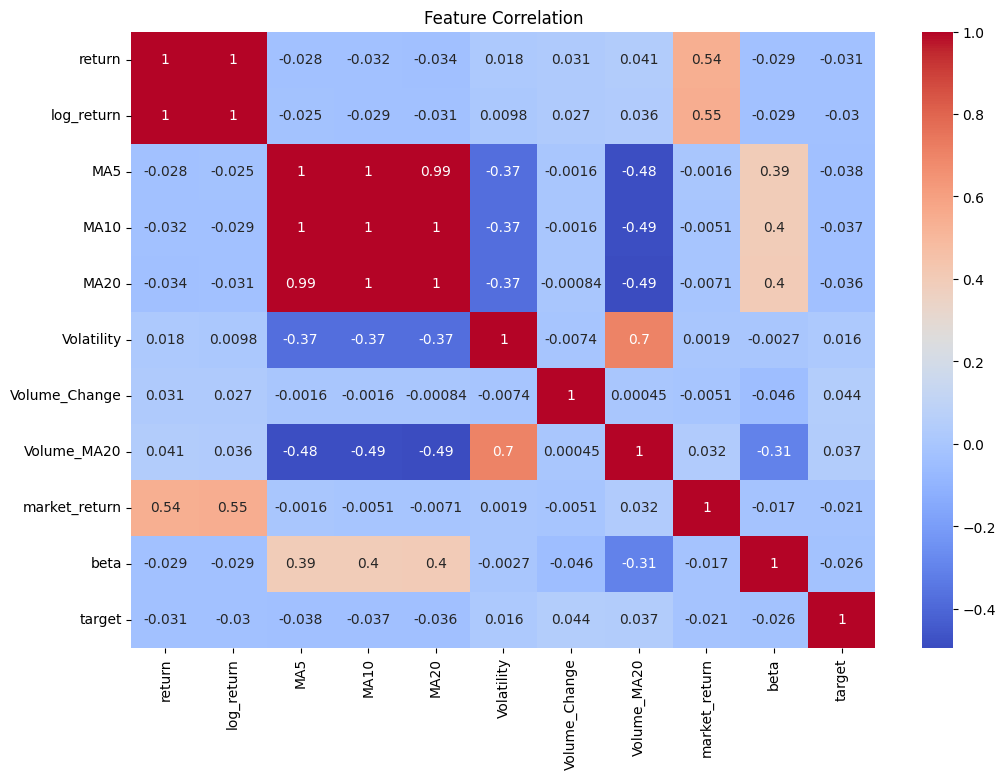

In [52]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

In [53]:
import os

processed_path = "/content/drive/MyDrive/PRISM/processed"

os.makedirs(processed_path, exist_ok=True)

In [54]:
df.to_csv(
    f"{processed_path}/TCS_processed.csv",
    index=False
)

In [55]:
saved_df = pd.read_csv(
    f"{processed_path}/TCS_processed.csv"
)

saved_df.head()

,Date,Close,High,Low,Open,Volume,return,log_return,MA5,MA10,MA20,Volatility,Volume_Change,Volume_MA20,market_return,beta,target
0,2019-04-02,1709.451782,1714.960003,1674.675708,1674.757900,3719663.0,0.023454,0.023183,1654.418677,1653.493872,1651.925623,0.010694,0.774869,2817120.55,0.003775,0.872846,0.000000
1,2019-04-03,1709.451782,1717.919746,1692.022699,1714.137874,2939886.0,0.000000,0.000000,1670.310376,1658.138855,1655.374432,0.010672,-0.209636,2756687.45,-0.005912,0.846219,-0.031164
2,2019-04-04,1656.177979,1709.780720,1650.340886,1708.506381,4397518.0,-0.031164,-0.031660,1677.972583,1657.456458,1656.459644,0.012978,0.495812,2854082.25,-0.003946,0.927309,0.016779
3,2019-04-05,1683.966309,1688.981173,1659.713511,1667.811459,3152103.0,0.016779,0.016639,1685.865039,1660.190063,1658.461536,0.013428,-0.283209,2879935.05,0.005859,0.938791,0.010960
4,2019-04-08,1702.422729,1705.916776,1671.140697,1692.762719,2194294.0,0.010960,0.010900,1692.294116,1665.542078,1660.823096,0.013548,-0.303863,2862655.55,-0.005267,0.903782,0.010020


#section 13

In [56]:
import os

raw_path = "/content/drive/MyDrive/PRISM/raw_data"
processed_path = "/content/drive/MyDrive/PRISM/processed"

os.makedirs(processed_path, exist_ok=True)

In [57]:
files = [
    file for file in os.listdir(raw_path)
    if file.endswith(".csv")
]

In [58]:
nifty = pd.read_csv(
    f"{raw_path}/^NSEI.csv"
)

nifty["Date"] = pd.to_datetime(nifty["Date"])

nifty["Close"] = pd.to_numeric(
    nifty["Close"],
    errors="coerce"
)

nifty["market_return"] = nifty["Close"].pct_change()

nifty = nifty[["Date","market_return"]]

In [59]:
for file in files:

    # Skip index files
    if file.startswith("^"):
        continue

    print(f"Processing {file}")

    df = pd.read_csv(
        os.path.join(raw_path,file)
    )

    # Date
    df["Date"] = pd.to_datetime(df["Date"])

    # Cleaning
    df = df.drop_duplicates()
    df = df.dropna()

    # Returns
    df["return"] = df["Close"].pct_change()

    df["log_return"] = np.log(
        df["Close"] /
        df["Close"].shift(1)
    )

    # Moving averages
    df["MA5"] = df["Close"].rolling(5).mean()

    df["MA10"] = df["Close"].rolling(10).mean()

    df["MA20"] = df["Close"].rolling(20).mean()

    # Volatility
    df["Volatility"] = (
        df["return"]
        .rolling(20)
        .std()
    )

    # Volume
    df["Volume_Change"] = (
        df["Volume"]
        .pct_change()
    )

    df["Volume_MA20"] = (
        df["Volume"]
        .rolling(20)
        .mean()
    )

    # Merge with market
    df = pd.merge(
        df,
        nifty,
        on="Date",
        how="inner"
    )

    # Beta
    covariance = (
        df["return"]
        .rolling(60)
        .cov(df["market_return"])
    )

    variance = (
        df["market_return"]
        .rolling(60)
        .var()
    )

    df["beta"] = covariance / variance

    # Target
    df["target"] = df["return"].shift(-1)

    # Remove NaNs created by rolling windows
    df.dropna(inplace=True)

    # Save
    df.to_csv(
        os.path.join(
            processed_path,
            file.replace(".csv","_processed.csv")
        ),
        index=False
    )

Processing 3MINDIA.NS.csv


KeyError: 'Date'